# $a$（pc）采样、直方图与均值

本 Notebook 只调用 `p_a_j.py` 中现有的 Appendix D 采样器，生成 $N=10^5$ 个半长轴 $a$（单位 pc），绘制直方图并计算样本均值。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# 同时兼容从项目根目录或 notebooks 目录启动 Jupyter。
current_directory = Path.cwd().resolve()
project_directory = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)
if str(project_directory) not in sys.path:
    sys.path.insert(0, str(project_directory))

from p_a_j import sample_initial_orbital_parameters

In [2]:
# 固定种子使每次重新运行 Notebook 都得到相同的随机样本。
sample_count = 100_000
random_seed = 12345
rng = np.random.default_rng(random_seed)

# 其余物理参数使用 p_a_j.py 的默认值：
# m_PBH=30 M_sun、f_PBH=1、10^-6 pc < a < 1 pc。
orbital_samples = sample_initial_orbital_parameters(
    sample_count=sample_count,
    rng=rng,
)
a_pc = orbital_samples.semi_major_axis_pc

In [3]:
mean_a_pc = np.mean(a_pc)

print(f"样本数 N = {a_pc.size:,}")
print(f"a 的样本均值 = {mean_a_pc:.8f} pc")

样本数 N = 100,000
a 的样本均值 = 0.01054027 pc


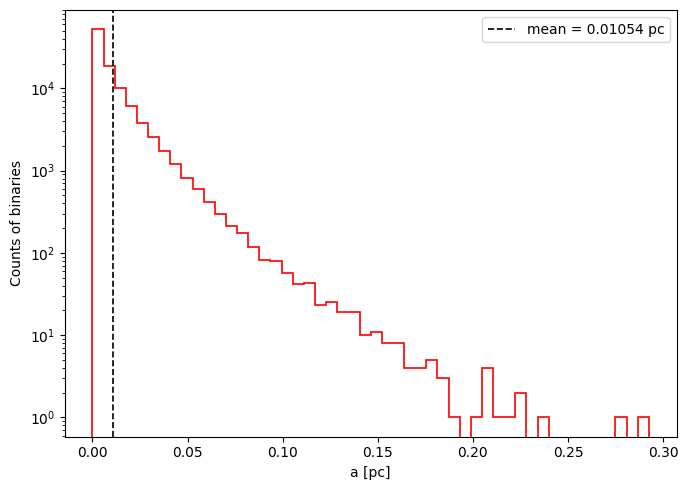

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 5.0))

ax.hist(
    a_pc,
    bins=50,
    histtype="step",
    color="red",
    linewidth=1.2,
)
ax.axvline(
    mean_a_pc,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=fr"mean = {mean_a_pc:.5f} pc",
)

ax.set_yscale("log")
ax.set_xlabel("a [pc]")
ax.set_ylabel("Counts of binaries")
ax.legend()
fig.tight_layout()
plt.show()